# Crawling

In [ ]:
"""
Sentinel-2 L2A (CDSE openEO) per-tile + ekstraksi KELAS PER PIKSEL -> CSV.

Setiap baris CSV = satu piksel, dengan penanda poligon asalnya:
  - poligon_id : ID stabil poligon, mis. "Sawah_0012" (nama kelas + nomor fitur di file sumbernya)
  - poligon_no : nomor fitur (urutan baris) di shapefile sumber, mulai dari 0
  - sampel_id  : indeks poligon pada GeoDataFrame gabungan (internal)

Poligon sampel masuk ke SEMUA tile yang dilewatinya. Piksel di zona overlap antar-tile
hanya diambil sekali (dimiliki sel grid-nya).

Pakai (script):   python sentinel2_piksel.py
Pakai (notebook): from sentinel2_piksel import main; main()
"""

import threading
import time
from datetime import datetime
from pathlib import Path

import geopandas as gpd
import numpy as np
import openeo
import pandas as pd
import rasterio
from openeo.extra.job_management import CsvJobDatabase, MultiBackendJobManager
from rasterio.features import rasterize
from rasterio.mask import mask as rio_mask
from rasterio.warp import transform as warp_transform
from rasterio.windows import Window
from shapely.geometry import box
from shapely.validation import make_valid

# ==============================================================================
# KONFIGURASI
# ==============================================================================
SUMBER = {  # nama kelas: (file, kode label)
   "Sawah": ("/content/drive/MyDrive/Crawling/sawah.zip", 1),
    "Bangunan": ("/content/drive/MyDrive/Crawling/bangunan.zip", 2),
    "Hutan": ("/content/drive/MyDrive/Crawling/Lahan Hijau.zip", 3),
    "Danau": ("/content/drive/MyDrive/Crawling/Danau.zip", 4),
    "Laut": ("/content/drive/MyDrive/Crawling/Laut.zip", 5),
    "Mangrove": ("/content/drive/MyDrive/Crawling/Magruve.zip", 6),
}

TILE_DEG = 0.20      # ukuran tile ~22 km (~2200 x 2200 piksel @10 m)
BUFFER_DEG = 0.005   # margin ~500 m di sekeliling sampel

TANGGAL = ["2026-09-01", "2026-09-30"]
BANDS = ["B02", "B03", "B04", "B08", "B11"]  # Blue, Green, Red, NIR, SWIR
PAKAI_MASK_SCL = True  # mask awan/bayangan per piksel pakai band SCL
MAX_CLOUD = 30         # filter awan level scene (kalau PAKAI_MASK_SCL=False, pakai ~10)

PARALEL = 2            # job bersamaan (akun gratis CDSE biasanya max 2)

# Ekstraksi piksel
MAKS_PIKSEL_PER_POLIGON = 2000  # None = ambil SEMUA piksel (hati-hati: poligon laut/hutan bisa jutaan -> CSV sangat besar)
SEED = 42
BUAT_RASTER_LABEL = True        # buat label_<tile>.tif di samping citra tiap tile

OUT_DIR = Path("hasil_s2_piksel")
JOB_DB_PATH = OUT_DIR / "daftar_job.csv"
PETA_CSV = OUT_DIR / "peta_sampel_tile.csv"
PIKSEL_OUT = OUT_DIR / "piksel_s2.csv"


# ==============================================================================
# 1. BACA & GABUNGKAN SAMPEL
# ==============================================================================
def baca_semua() -> gpd.GeoDataFrame:
    bagian = []
    for nama, (file, label) in SUMBER.items():
        g = gpd.read_file(file).to_crs("EPSG:4326")
        # nomor fitur asli di file sumber (dicatat SEBELUM filter agar tetap stabil)
        g["poligon_no"] = np.arange(len(g))
        g = g[g.geometry.notna() & ~g.geometry.is_empty].copy()
        g["geometry"] = g.geometry.apply(lambda x: x if x.is_valid else make_valid(x))
        g["label_teks"] = nama
        g["label"] = label
        g["poligon_id"] = [f"{nama}_{n:04d}" for n in g["poligon_no"]]
        g = g[["poligon_id", "poligon_no", "label", "label_teks", "geometry"]]
        print(f"Jumlah sampel {nama:<9}: {len(g)}  bounds={[round(v, 3) for v in g.total_bounds]}")
        bagian.append(g)

    gdf = gpd.GeoDataFrame(pd.concat(bagian, ignore_index=True), crs="EPSG:4326")
    print(f"Total sampel gabungan   : {len(gdf)}")
    return gdf


# ==============================================================================
# 2. BAGI JADI TILE (poligon masuk ke semua sel yang dilewatinya)
# ==============================================================================
def buat_tile(gdf: gpd.GeoDataFrame):
    T, B = TILE_DEG, BUFFER_DEG
    peta, batas, sel_xy = [], {}, {}

    for idx, geom in gdf.geometry.items():
        minx, miny, maxx, maxy = geom.bounds
        for gx in range(int(np.floor(minx / T)), int(np.floor(maxx / T)) + 1):
            for gy in range(int(np.floor(miny / T)), int(np.floor(maxy / T)) + 1):
                sel = box(gx * T, gy * T, (gx + 1) * T, (gy + 1) * T)
                if not geom.intersects(sel):
                    continue
                bagian = geom.intersection(sel)
                if bagian.is_empty:
                    continue
                b = bagian.bounds
                tid = f"x{gx}_y{gy}"
                peta.append({"tile_id": tid, "sampel_id": idx, "poligon_id": gdf.at[idx, "poligon_id"]})
                sel_xy[tid] = (gx, gy)
                if tid in batas:
                    o = batas[tid]
                    batas[tid] = (min(o[0], b[0]), min(o[1], b[1]), max(o[2], b[2]), max(o[3], b[3]))
                else:
                    batas[tid] = b

    tiles = pd.DataFrame(
        [
            {
                "tile_id": tid,
                "gx": sel_xy[tid][0],
                "gy": sel_xy[tid][1],
                "west": b[0] - B,
                "south": b[1] - B,
                "east": b[2] + B,
                "north": b[3] + B,
            }
            for tid, b in batas.items()
        ]
    )
    peta = pd.DataFrame(peta)
    tiles["n_sampel"] = tiles["tile_id"].map(peta.groupby("tile_id")["sampel_id"].nunique())

    lebar_km = (tiles.east - tiles.west) * 111.32 * np.cos(np.radians((tiles.north + tiles.south) / 2))
    tinggi_km = (tiles.north - tiles.south) * 110.57
    print(f"\nJumlah tile (job)       : {len(tiles)}")
    print(f"Ukuran tile terbesar    : {lebar_km.max():.1f} km x {tinggi_km.max():.1f} km")
    print(f"Total area diunduh      : {(lebar_km * tinggi_km).sum():,.0f} km2")
    return tiles, peta


# ==============================================================================
# 3. JALANKAN BATCH JOB PER TILE
# ==============================================================================
def _jam() -> str:
    return datetime.now().strftime("%H:%M:%S")


def start_job(row, connection, **kwargs):
    print(f"[{_jam()}] >> Mengirim job tile {row['tile_id']} ({row.get('n_sampel', '?')} poligon)...", flush=True)
    bbox = {
        "west": float(row["west"]),
        "south": float(row["south"]),
        "east": float(row["east"]),
        "north": float(row["north"]),
    }
    bands = BANDS + ["SCL"] if PAKAI_MASK_SCL else BANDS
    cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=TANGGAL,
        bands=bands,
        max_cloud_cover=MAX_CLOUD,
    )

    if PAKAI_MASK_SCL:
        scl = cube.band("SCL")
        # 1=jenuh, 3=bayangan awan, 8/9=awan sedang/tinggi, 10=cirrus
        mask_awan = (scl == 1) | (scl == 3) | (scl == 8) | (scl == 9) | (scl == 10)
        cube = cube.filter_bands(BANDS).mask(mask_awan)

    komposit = cube.median_time()
    return komposit.create_job(title=f"s2_{row['tile_id']}", out_format="GTiff")


INTERVAL_LAPOR = 30  # detik antar laporan progres di terminal


class ManagerBerlapor(MultiBackendJobManager):
    """Manager job yang mencetak pesan saat job selesai / gagal."""

    def on_job_done(self, job, row):
        print(f"[{_jam()}] [OK]    Tile {row['tile_id']} selesai (job {job.job_id}), mengunduh hasil...", flush=True)
        super().on_job_done(job, row)
        print(f"[{_jam()}] [OK]    Tile {row['tile_id']} terunduh.", flush=True)

    def on_job_error(self, job, row):
        print(f"[{_jam()}] [ERROR] Tile {row['tile_id']} gagal (job {job.job_id}). Log disimpan di folder job.", flush=True)
        super().on_job_error(job, row)


def _lapor_berkala(job_db, berhenti: threading.Event):
    mulai = time.time()
    while not berhenti.wait(INTERVAL_LAPOR):
        try:
            df = job_db.read()
        except Exception:  # file sedang ditulis manager; lewati satu siklus
            continue
        n = len(df)
        hitung = df["status"].value_counts().to_dict()
        selesai = hitung.get("finished", 0)
        gagal = sum(hitung.get(s, 0) for s in ("error", "start_failed", "skipped"))
        jalan = hitung.get("running", 0) + hitung.get("queued", 0) + hitung.get("created", 0)
        belum = hitung.get("not_started", 0)
        persen = 100 * selesai / n if n else 0
        menit = (time.time() - mulai) / 60
        print(
            f"[{_jam()}] Progres job: {selesai}/{n} selesai ({persen:.0f}%) | "
            f"berjalan/antre {jalan} | belum mulai {belum} | gagal {gagal} | {menit:.1f} menit",
            flush=True,
        )


def jalankan_job(tiles: pd.DataFrame, ulangi_error: bool = True):
    OUT_DIR.mkdir(exist_ok=True)

    conn = openeo.connect("openeo.dataspace.copernicus.eu")
    conn.authenticate_oidc()

    manager = ManagerBerlapor(root_dir=OUT_DIR, poll_sleep=30)
    manager.add_backend("cdse", connection=conn, parallel_jobs=PARALEL)

    job_db = CsvJobDatabase(JOB_DB_PATH)
    if not job_db.exists():
        job_db.initialize_from_df(tiles)
    elif ulangi_error:
        df = job_db.read()
        gagal = df["status"].isin(["error", "start_failed", "skipped"])
        if gagal.any():
            print(f"Mengulang {int(gagal.sum())} job yang sebelumnya gagal.")
            df.loc[gagal, "status"] = "not_started"
            job_db.persist(df)

    # thread pemantau: cetak ringkasan status job tiap INTERVAL_LAPOR detik
    berhenti = threading.Event()
    pemantau = threading.Thread(target=_lapor_berkala, args=(job_db, berhenti), daemon=True)
    pemantau.start()
    try:
        manager.run_jobs(start_job=start_job, job_db=job_db)
    finally:
        berhenti.set()
        pemantau.join(timeout=5)

    df = job_db.read()
    print("\nRingkasan status job:")
    print(df["status"].value_counts().to_string())
    return df


# ==============================================================================
# 4. EKSTRAK KELAS PER PIKSEL -> CSV
# ==============================================================================
def _nama_band(src) -> list:
    desc = list(src.descriptions or [])
    if len(desc) == src.count and all(desc) and set(BANDS) <= set(desc):
        return desc
    return BANDS  # asumsi urutan band sama dengan permintaan


def _valid_mask(data, nodata, masked=None):
    """data: (band, H, W). Piksel valid = semua band terbatas, > 0, bukan nodata."""
    ok = np.isfinite(data).all(axis=0) & (data > 0).all(axis=0)
    if nodata is not None and not np.isnan(nodata):
        ok &= ~(data == nodata).any(axis=0)
    if masked is not None:
        ok &= ~masked
    return ok


def _piksel_geom(src, geom):
    """Semua piksel valid yang pusatnya di dalam geometri.
    Return (nilai[band, n], baris_raster, kolom_raster, x, y) dalam CRS raster, atau None."""
    nodata = src.nodata

    if geom.geom_type == "Point":
        rr, cc = src.index(geom.x, geom.y)
        if not (0 <= rr < src.height and 0 <= cc < src.width):
            return None
        data = src.read(window=Window(cc, rr, 1, 1)).astype("float64")  # (band,1,1)
        ok = _valid_mask(data, nodata)
        row0, col0 = rr, cc
    else:
        ok = None
        for all_touched in (False, True):  # poligon sangat kecil: coba lagi dengan all_touched
            try:
                arr, tr = rio_mask(src, [geom], crop=True, all_touched=all_touched, filled=False)
            except ValueError:  # tidak beririsan dengan raster
                return None
            data = np.ma.getdata(arr).astype("float64")
            ok = _valid_mask(data, nodata, np.ma.getmaskarray(arr).any(axis=0))
            row0 = int(round((tr.f - src.transform.f) / src.transform.e))
            col0 = int(round((tr.c - src.transform.c) / src.transform.a))
            if ok.any():
                break
        if ok is None or not ok.any():
            return None

    r_idx, c_idx = np.nonzero(ok)
    if len(r_idx) == 0:
        return None
    nilai = data[:, r_idx, c_idx]
    px_row, px_col = row0 + r_idx, col0 + c_idx
    xs, ys = rasterio.transform.xy(src.transform, px_row, px_col)
    return nilai, px_row, px_col, np.asarray(xs), np.asarray(ys)


def tambah_indeks(df: pd.DataFrame) -> pd.DataFrame:
    e = 1e-9
    df["NDVI"] = (df["B08"] - df["B04"]) / (df["B08"] + df["B04"] + e)
    df["NDWI"] = (df["B03"] - df["B08"]) / (df["B03"] + df["B08"] + e)
    df["MNDWI"] = (df["B03"] - df["B11"]) / (df["B03"] + df["B11"] + e)
    df["NDBI"] = (df["B11"] - df["B08"]) / (df["B11"] + df["B08"] + e)
    return df


def _tif_tile(r):
    tifs = sorted(p for p in OUT_DIR.glob(f"job_{r['id']}/*.tif") if not p.name.startswith("label_"))
    return tifs[0] if tifs else None


def ekstrak_piksel(gdf, db, peta) -> pd.DataFrame:
    rng = np.random.default_rng(SEED)
    T = TILE_DEG
    potongan = []
    selesai = db[db["status"] == "finished"]
    print(f"\nEkstraksi piksel dari {len(selesai)} tile yang selesai...")

    total_tile = len(selesai)
    total_piksel = 0
    t0 = time.time()

    for no_tile, (_, r) in enumerate(selesai.iterrows(), start=1):
        tif = _tif_tile(r)
        if tif is None:
            print(f"  [!] File .tif tidak ditemukan untuk tile {r['tile_id']} (job {r['id']})")
            continue

        cx0, cy0 = int(r["gx"]) * T, int(r["gy"]) * T
        ids = peta.loc[peta["tile_id"] == r["tile_id"], "sampel_id"].unique()
        n_poli = len(ids)
        piksel_tile = 0
        print(f"[{_jam()}] Tile {no_tile}/{total_tile} ({r['tile_id']}): {n_poli} poligon", flush=True)

        with rasterio.open(tif) as src:
            nama_band = _nama_band(src)
            sub_r = gdf.loc[ids].to_crs(src.crs)

            for no_poli, (idx, row) in enumerate(sub_r.iterrows(), start=1):
                if no_poli % 25 == 0 or no_poli == n_poli:
                    print(
                        f"    poligon {no_poli}/{n_poli} | piksel tile ini: {piksel_tile:,} | "
                        f"total: {total_piksel:,} | {(time.time() - t0) / 60:.1f} menit",
                        end="\r", flush=True,
                    )
                hasil = _piksel_geom(src, row.geometry)
                if hasil is None:
                    continue
                nilai, px_row, px_col, xs, ys = hasil

                lon, lat = warp_transform(src.crs, "EPSG:4326", xs.tolist(), ys.tolist())
                lon, lat = np.asarray(lon), np.asarray(lat)

                # hanya piksel yang pusatnya di dalam sel grid tile ini -> tidak ada duplikat antar-tile
                pilih = np.flatnonzero((lon >= cx0) & (lon < cx0 + T) & (lat >= cy0) & (lat < cy0 + T))
                if len(pilih) == 0:
                    continue
                if MAKS_PIKSEL_PER_POLIGON and len(pilih) > MAKS_PIKSEL_PER_POLIGON:
                    pilih = rng.choice(pilih, MAKS_PIKSEL_PER_POLIGON, replace=False)

                d = {
                    "poligon_id": row["poligon_id"],   # penanda poligon asal
                    "poligon_no": row["poligon_no"],
                    "sampel_id": idx,
                    "tile_id": r["tile_id"],
                    "label": row["label"],
                    "label_teks": row["label_teks"],
                    "px_row": px_row[pilih],
                    "px_col": px_col[pilih],
                    "lon": lon[pilih],
                    "lat": lat[pilih],
                }
                for i, nb in enumerate(nama_band):
                    d[nb] = nilai[i, pilih]
                potongan.append(pd.DataFrame(d))
                piksel_tile += len(pilih)
                total_piksel += len(pilih)

        print(f"\n    -> tile {r['tile_id']} selesai: {piksel_tile:,} piksel", flush=True)

    if not potongan:
        print("Tidak ada piksel yang berhasil diekstrak.")
        return pd.DataFrame()

    df = pd.concat(potongan, ignore_index=True)

    # piksel yang sama dimiliki poligon kelas berbeda = label ambigu -> dibuang
    kunci = ["tile_id", "px_row", "px_col"]
    ganda = df.duplicated(kunci, keep=False)
    konflik = ganda & (df.groupby(kunci)["label"].transform("nunique") > 1)
    if konflik.any():
        print(f"Membuang {int(konflik.sum())} piksel dengan label bertabrakan antar-kelas.")
    df = df[~konflik]

    # piksel yang sama dimiliki >1 poligon dari kelas yang sama: simpan satu baris saja
    # (poligon_id = poligon yang pertama memprosesnya)
    n_sebelum = len(df)
    df = df.drop_duplicates(kunci).reset_index(drop=True)
    if n_sebelum != len(df):
        print(f"Menghapus {n_sebelum - len(df)} piksel ganda (poligon sekelas yang saling tumpang tindih).")

    df = tambah_indeks(df)

    OUT_DIR.mkdir(exist_ok=True)
    df.to_csv(PIKSEL_OUT, index=False)
    print(f"\nTersimpan: {PIKSEL_OUT}")
    print(f"Total piksel berlabel: {len(df):,}")
    print(df.groupby("label_teks").size().to_string())
    print(f"Jumlah poligon yang menghasilkan piksel: {df['poligon_id'].nunique()}")
    return df


# ==============================================================================
# 5. (OPSIONAL) RASTER LABEL GeoTIFF SEJAJAR DENGAN CITRA TILE
# ==============================================================================
def buat_raster_label(gdf, db, peta):
    """Tulis label_<tile>.tif (uint8, 0 = tanpa label) pada grid yang sama dengan citra tile."""
    selesai = db[db["status"] == "finished"]
    total = len(selesai)
    for no, (_, r) in enumerate(selesai.iterrows(), start=1):
        tif = _tif_tile(r)
        if tif is None:
            continue
        print(f"[{_jam()}] Raster label {no}/{total}: tile {r['tile_id']}", flush=True)
        ids = peta.loc[peta["tile_id"] == r["tile_id"], "sampel_id"].unique()
        with rasterio.open(tif) as src:
            sub_r = gdf.loc[ids].to_crs(src.crs)
            shapes = [(g, int(l)) for g, l in zip(sub_r.geometry, sub_r["label"])]
            lab = rasterize(
                shapes, out_shape=(src.height, src.width), transform=src.transform,
                fill=0, dtype="uint8",
            )
            profil = dict(
                driver="GTiff", height=src.height, width=src.width, count=1, dtype="uint8",
                crs=src.crs, transform=src.transform, nodata=0, compress="deflate",
            )
            keluar = tif.with_name(f"label_{r['tile_id']}.tif")
            with rasterio.open(keluar, "w", **profil) as dst:
                dst.write(lab, 1)
    print("Raster label selesai (label_<tile>.tif di folder tiap job).")


# ==============================================================================
# MAIN
# ==============================================================================
def main(jalankan: bool = True, ekstrak: bool = True, ulangi_error: bool = True):
    gdf = baca_semua()
    tiles, peta = buat_tile(gdf)

    OUT_DIR.mkdir(exist_ok=True)
    tiles.to_csv(OUT_DIR / "rencana_tile.csv", index=False)
    peta.to_csv(PETA_CSV, index=False)
    # tabel referensi poligon (tanpa geometri) untuk join dengan CSV piksel
    gdf.drop(columns="geometry").assign(
        luas_derajat2=gdf.geometry.area
    ).to_csv(OUT_DIR / "daftar_poligon.csv", index_label="sampel_id")

    if jalankan:
        db = jalankan_job(tiles, ulangi_error=ulangi_error)
    else:
        db = CsvJobDatabase(JOB_DB_PATH).read()

    hasil = None
    if ekstrak:
        hasil = ekstrak_piksel(gdf, db, peta)
    if BUAT_RASTER_LABEL:
        buat_raster_label(gdf, db, peta)
    return hasil if hasil is not None else db


if __name__ == "__main__":
    main()

# Modeling Random Forest

In [7]:
"""
Klasifikasi RANDOM FOREST berdasarkan CENTROID tiap poligon (bukan per piksel).

Alur sama dengan klasifikasi_knn.py, sehingga hasilnya bisa dibandingkan langsung:
  1. Baca piksel_s2.csv (hasil sentinel2_piksel.py).
  2. Agregasi: semua piksel dalam satu poligon -> satu baris centroid.
  3. Bagi TRAIN/TEST di tingkat POLIGON (stratified, SEED sama dengan KNN
     -> pembagian train/test identik dengan KNN).
  4. Random Forest (tanpa standarisasi), cari hyperparameter dengan cross-validation.
  5. Evaluasi di data uji + pentingnya fitur, simpan semua hasil.

Pakai (script):   python klasifikasi_rf.py [path/piksel_s2.csv]
Pakai (notebook): from klasifikasi_rf import main; main()
"""

import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

# ==============================================================================
# KONFIGURASI
# ==============================================================================
CSV_PIKSEL = Path("dataset.csv")
OUT_DIR = Path("hasil_rf")

FITUR = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI", "MNDWI", "NDBI"]
AGREGASI = "mean"       # "mean" (centroid) atau "median" (lebih tahan outlier)
MIN_PIKSEL = 1          # poligon dengan piksel kurang dari ini dibuang

UKURAN_TEST = 0.30      # proporsi poligon untuk data uji
SEED = 42               # samakan dengan KNN agar split train/test identik
MAKS_FOLD = 5           # jumlah fold cross-validation (otomatis turun jika kelas sedikit)

# Ruang pencarian hyperparameter
GRID = {
    "n_estimators": [200, 500],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", None],
    "class_weight": [None, "balanced"],
}


# ==============================================================================
# 1. CENTROID PER POLIGON
# ==============================================================================
def buat_centroid(df: pd.DataFrame) -> pd.DataFrame:
    """Satu baris per poligon: nilai fitur = rata-rata (atau median) semua pikselnya."""
    hilang = sorted(set(FITUR) - set(df.columns))
    if hilang:
        raise KeyError(f"Kolom fitur tidak ada di CSV: {hilang}")

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=FITUR)

    agg = df.groupby("poligon_id")[FITUR].agg(AGREGASI)
    info = df.groupby("poligon_id").agg(
        label=("label", "first"),
        label_teks=("label_teks", "first"),
        n_piksel=("label", "size"),
        lon_centroid=("lon", "mean"),
        lat_centroid=("lat", "mean"),
    )
    n_label = df.groupby("poligon_id")["label"].nunique()
    if (n_label > 1).any():
        print(f"[!] {int((n_label > 1).sum())} poligon punya >1 label, memakai label pertama.")

    cen = info.join(agg).reset_index()
    cen = cen[cen["n_piksel"] >= MIN_PIKSEL].reset_index(drop=True)
    return cen


# ==============================================================================
# 2. LATIH + EVALUASI
# ==============================================================================
def latih_rf(cen: pd.DataFrame):
    X = cen[FITUR].to_numpy()
    y = cen["label_teks"].to_numpy()

    jumlah = cen["label_teks"].value_counts()
    print("\nJumlah poligon per kelas:")
    print(jumlah.to_string())
    if jumlah.min() < 3:
        sedikit = jumlah[jumlah < 3].index.tolist()
        raise ValueError(
            f"Kelas {sedikit} hanya punya <3 poligon; tidak cukup untuk split train/test + CV. "
            "Tambah sampel poligon untuk kelas tersebut."
        )

    idx_train, idx_test = train_test_split(
        np.arange(len(cen)), test_size=UKURAN_TEST, random_state=SEED, stratify=y
    )
    X_tr, X_te, y_tr, y_te = X[idx_train], X[idx_test], y[idx_train], y[idx_test]
    print(f"\nTrain: {len(idx_train)} poligon | Test: {len(idx_test)} poligon")

    n_fold = max(int(min(MAKS_FOLD, pd.Series(y_tr).value_counts().min())), 2)
    n_kombinasi = int(np.prod([len(v) for v in GRID.values()]))

    # n_jobs paralel di level grid search; tiap forest 1 thread agar CPU tidak berebut
    rf = RandomForestClassifier(random_state=SEED, n_jobs=1)
    cv = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=SEED)
    gs = GridSearchCV(rf, GRID, cv=cv, scoring="f1_macro", n_jobs=-1, refit=True, verbose=1)
    print(f"Mencari hyperparameter terbaik ({n_kombinasi} kombinasi x {n_fold}-fold CV, F1 macro)...")
    gs.fit(X_tr, y_tr)
    print(f"Parameter terbaik : {gs.best_params_}")
    print(f"F1 macro CV       : {gs.best_score_:.4f}")

    model = gs.best_estimator_
    pred = model.predict(X_te)
    return model, gs, idx_train, idx_test, y_te, pred


def evaluasi(model, cen, idx_test, y_te, pred):
    kelas = sorted(cen["label_teks"].unique())

    acc = accuracy_score(y_te, pred)
    f1m = f1_score(y_te, pred, average="macro")
    kappa = cohen_kappa_score(y_te, pred)
    print("\n" + "=" * 60)
    print("HASIL PADA DATA UJI (tingkat poligon) - RANDOM FOREST")
    print("=" * 60)
    print(f"Akurasi    : {acc:.4f}")
    print(f"F1 macro   : {f1m:.4f}")
    print(f"Kappa      : {kappa:.4f}")
    print("\nLaporan per kelas:")
    print(classification_report(y_te, pred, labels=kelas, zero_division=0))

    cm = pd.DataFrame(
        confusion_matrix(y_te, pred, labels=kelas),
        index=[f"asli_{k}" for k in kelas],
        columns=[f"pred_{k}" for k in kelas],
    )
    print("Confusion matrix:")
    print(cm.to_string())

    uji = cen.iloc[idx_test][["poligon_id", "label_teks", "n_piksel"]].reset_index(drop=True)
    uji = uji.rename(columns={"label_teks": "kelas_asli"})
    uji["kelas_prediksi"] = pred
    uji["benar"] = uji["kelas_asli"] == uji["kelas_prediksi"]
    proba = model.predict_proba(cen.iloc[idx_test][FITUR].to_numpy())
    for j, k in enumerate(model.classes_):
        uji[f"prob_{k}"] = proba[:, j].round(3)

    penting = (
        pd.DataFrame({"fitur": FITUR, "kepentingan": model.feature_importances_})
        .sort_values("kepentingan", ascending=False)
        .reset_index(drop=True)
    )
    print("\nKepentingan fitur (Gini):")
    print(penting.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    return cm, uji, penting, dict(akurasi=acc, f1_macro=f1m, kappa=kappa)


def _plot(fn):
    try:
        import matplotlib

        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib tidak terpasang; gambar dilewati.")
        return
    fn(plt)


def simpan_cm_png(cm: pd.DataFrame, path: Path):
    def gambar(plt):
        fig, ax = plt.subplots(figsize=(6.5, 5.5))
        im = ax.imshow(cm.values, cmap="Greens")
        ax.set_xticks(range(cm.shape[1]), [c.replace("pred_", "") for c in cm.columns], rotation=45, ha="right")
        ax.set_yticks(range(cm.shape[0]), [c.replace("asli_", "") for c in cm.index])
        ax.set_xlabel("Prediksi")
        ax.set_ylabel("Kelas asli")
        ax.set_title("Confusion matrix Random Forest (data uji, per poligon)")
        batas = cm.values.max() / 2 if cm.values.max() else 0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, int(cm.values[i, j]), ha="center", va="center",
                        color="white" if cm.values[i, j] > batas else "black")
        fig.colorbar(im, ax=ax, fraction=0.046)
        fig.tight_layout()
        fig.savefig(path, dpi=150)
        plt.close(fig)

    _plot(gambar)


def simpan_penting_png(penting: pd.DataFrame, path: Path):
    def gambar(plt):
        p = penting.iloc[::-1]
        fig, ax = plt.subplots(figsize=(6, 4.5))
        ax.barh(p["fitur"], p["kepentingan"], color="#2e7d32")
        ax.set_xlabel("Kepentingan fitur (Gini)")
        ax.set_title("Kepentingan fitur Random Forest")
        fig.tight_layout()
        fig.savefig(path, dpi=150)
        plt.close(fig)

    _plot(gambar)


# ==============================================================================
# MAIN
# ==============================================================================
def main(csv_piksel: Path = CSV_PIKSEL):
    csv_piksel = Path(csv_piksel)
    OUT_DIR.mkdir(exist_ok=True)

    print(f"Membaca {csv_piksel} ...")
    df = pd.read_csv(csv_piksel)
    print(f"Total piksel : {len(df):,} | poligon: {df['poligon_id'].nunique()}")

    cen = buat_centroid(df)
    cen.to_csv(OUT_DIR / "centroid_poligon.csv", index=False)
    print(f"Centroid ({AGREGASI}) dibuat untuk {len(cen)} poligon -> {OUT_DIR / 'centroid_poligon.csv'}")

    model, gs, idx_train, idx_test, y_te, pred = latih_rf(cen)
    cm, uji, penting, metrik = evaluasi(model, cen, idx_test, y_te, pred)

    cen_split = cen[["poligon_id"]].copy()
    cen_split["subset"] = "train"
    cen_split.loc[idx_test, "subset"] = "test"
    cen_split.to_csv(OUT_DIR / "pembagian_train_test.csv", index=False)

    uji.to_csv(OUT_DIR / "prediksi_data_uji.csv", index=False)
    cm.to_csv(OUT_DIR / "confusion_matrix.csv")
    penting.to_csv(OUT_DIR / "kepentingan_fitur.csv", index=False)
    simpan_cm_png(cm, OUT_DIR / "confusion_matrix.png")
    simpan_penting_png(penting, OUT_DIR / "kepentingan_fitur.png")
    pd.DataFrame(gs.cv_results_).sort_values("rank_test_score").to_csv(
        OUT_DIR / "hasil_grid_search.csv", index=False
    )
    joblib.dump({"model": model, "fitur": FITUR, "agregasi": AGREGASI}, OUT_DIR / "model_rf.joblib")

    print(f"\nSemua keluaran tersimpan di folder: {OUT_DIR}/")
    return model, cen, metrik


if __name__ == "__main__":
    # abaikan argumen bawaan Jupyter (--f=...); pakai argumen hanya jika berupa path biasa
    arg = sys.argv[1] if len(sys.argv) > 1 and not sys.argv[1].startswith("-") else CSV_PIKSEL
    main(arg)

Membaca dataset.csv ...
Total piksel : 322,146 | poligon: 274
Centroid (mean) dibuat untuk 274 poligon -> hasil_rf\centroid_poligon.csv

Jumlah poligon per kelas:
label_teks
Bangunan    51
Sawah       51
Laut        50
Mangrove    49
Danau       46
Hutan       27

Train: 191 poligon | Test: 83 poligon
Mencari hyperparameter terbaik (72 kombinasi x 5-fold CV, F1 macro)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Parameter terbaik : {'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
F1 macro CV       : 0.9463

HASIL PADA DATA UJI (tingkat poligon) - RANDOM FOREST
Akurasi    : 0.9639
F1 macro   : 0.9654
Kappa      : 0.9563

Laporan per kelas:
              precision    recall  f1-score   support

    Bangunan       1.00      1.00      1.00        16
       Danau       0.92      0.86      0.89        14
       Hutan       1.00      1.00      1.00         8
        Laut       0.88      0.93      0.90        15
 

# Klasifikasi Model Random Forest

In [12]:
"""
Peta klasifikasi Random Forest (folium) dengan POLIGON PENUH (Lightweight & Cepat).

Menampilkan seluruh poligon sampel (~300 poligon) dari 6 kelas tutupan lahan:
1. Sawah
2. Bangunan
3. Hutan
4. Danau
5. Laut
6. Mangrove

Setiap poligon ditampilkan sebagai bidang penuh (bukan sekadar titik centroid),
beserta kelas aslinya dan HASIL PREDIKSI (khusus untuk data uji).

Fitur Peta:
- Ringan & Responsif: Menggunakan geometri poligon shapefile (bukan ratusan ribu kotak piksel).
- Layer 6 Kelas: Poligon dikelompokkan per kelas dengan warna standar GIS.
- Layer Sorotan Data Uji: Menampilkan outline biru pada 83 poligon data uji.
- Layer Salah Klasifikasi: Outline oranye putus-putus + marker tanda seru pada poligon yang salah diprediksi.
- Popup & Tooltip: Menampilkan ID, kelas asli, subset (latih/uji), prediksi model, keyakinan, dan indeks spektral.
- Legenda Interaktif: Menampilkan ringkasan kelas dan akurasi data uji (96.4%).
"""

from pathlib import Path
import folium
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.validation import make_valid

# ==============================================================================
# KONFIGURASI
# ==============================================================================
SUMBER = {
    "Sawah": "sawah.zip",
    "Bangunan": "bangunan.zip",
    "Hutan": "Hutan.zip",
    "Danau": "Danau.zip",
    "Laut": "laut2.zip",
    "Mangrove": "Mangrove.zip",
}

WARNA = {
    "Sawah": "#a6d96a",     # hijau muda
    "Bangunan": "#e31a1c",  # merah
    "Hutan": "#1a9641",     # hijau tua
    "Danau": "#4eb3d3",     # biru muda
    "Laut": "#0b3c8c",      # biru tua
    "Mangrove": "#8c510a",  # cokelat
}

DIR_RF = Path("hasil_rf")
PETA_OUT = "peta_klasifikasi_rf.html"

# Penyederhanaan geometri agar ukuran HTML ringan (~3 meter dalam derajat)
SIMPLIFY_DEG = 0.00003


# ==============================================================================
# 1. BACA SHAPEFILE SEMUA KELAS (GEOMETRI POLIGON SAMPEL)
# ==============================================================================
def baca_semua_poligon() -> gpd.GeoDataFrame:
    """Membaca semua file shapefile dan menyusun poligon_id identik dengan saat ekstraksi fitur."""
    bagian = []
    for nama, file in SUMBER.items():
        g = gpd.read_file(file).to_crs("EPSG:4326")
        g["poligon_no"] = np.arange(len(g))
        g = g[g.geometry.notna() & ~g.geometry.is_empty].copy()
        g["geometry"] = g.geometry.apply(lambda x: x if x.is_valid else make_valid(x))
        g["poligon_id"] = [f"{nama}_{n:04d}" for n in g["poligon_no"]]
        g["kelas"] = nama
        bagian.append(g[["poligon_id", "kelas", "geometry"]])

    gdf = gpd.GeoDataFrame(pd.concat(bagian, ignore_index=True), crs="EPSG:4326")
    if SIMPLIFY_DEG:
        gdf["geometry"] = gdf.geometry.simplify(SIMPLIFY_DEG, preserve_topology=True)
    return gdf


# ==============================================================================
# 2. GABUNGKAN DATA HASIL MODELING RANDOM FOREST
# ==============================================================================
def siapkan_data_peta(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Menggabungkan geometri poligon dengan metadata centroid, split data, dan hasil evaluasi model."""
    cen = pd.read_csv(DIR_RF / "centroid_poligon.csv")
    split = pd.read_csv(DIR_RF / "pembagian_train_test.csv")
    uji = pd.read_csv(DIR_RF / "prediksi_data_uji.csv")

    # Hitung tingkat keyakinan (probabilitas maksimum kelas)
    prob_cols = [c for c in uji.columns if c.startswith("prob_")]
    if prob_cols:
        uji["keyakinan"] = uji[prob_cols].max(axis=1)
    else:
        uji["keyakinan"] = np.nan

    # Fitur spektral yang ingin ditampilkan di popup jika tersedia
    fitur_popup = [c for c in ["n_piksel", "NDVI", "NDWI", "MNDWI", "NDBI"] if c in cen.columns]

    h = gdf.merge(cen[["poligon_id"] + fitur_popup], on="poligon_id", how="left")
    h = h.merge(split, on="poligon_id", how="left")
    h = h.merge(uji[["poligon_id", "kelas_prediksi", "benar", "keyakinan"]], on="poligon_id", how="left")

    # Format teks tooltip dan popup
    def teks_tip(r):
        if r["subset"] == "test":
            simbol = "✓ Benar" if r["benar"] else f"✗ SALAH (Prediksi: {r['kelas_prediksi']})"
            return f"[Data Uji] {r['poligon_id']} | Asli: {r['kelas']} | {simbol}"
        elif r["subset"] == "train":
            return f"[Data Latih] {r['poligon_id']} | Kelas: {r['kelas']}"
        return f"[Tanpa Piksel Valid] {r['poligon_id']} | Kelas: {r['kelas']}"

    def teks_popup(r):
        is_test = r["subset"] == "test"
        is_train = r["subset"] == "train"

        if is_test:
            subset_badge = "<span style='background:#0d6efd; color:white; padding:2px 6px; border-radius:3px; font-size:11px;'>Data Uji (Testing)</span>"
            status_badge = (
                "<span style='background:#28a745; color:white; padding:2px 6px; border-radius:3px; font-size:11px;'>Benar</span>"
                if r["benar"]
                else "<span style='background:#dc3545; color:white; padding:2px 6px; border-radius:3px; font-size:11px;'>SALAH</span>"
            )
            pred_val = f"<b style='color:#0d6efd;'>{r['kelas_prediksi']}</b>"
            keyak_val = f"{r['keyakinan']:.1%}" if pd.notna(r["keyakinan"]) else "-"
        elif is_train:
            subset_badge = "<span style='background:#6c757d; color:white; padding:2px 6px; border-radius:3px; font-size:11px;'>Data Latih (Training)</span>"
            status_badge = "<span style='color:#6c757d;'>Sampel Training</span>"
            pred_val = "<span style='color:#6c757d;'>- (Data Latih)</span>"
            keyak_val = "-"
        else:
            subset_badge = "<span style='background:#ffc107; color:black; padding:2px 6px; border-radius:3px; font-size:11px;'>Tanpa Data Piksel</span>"
            status_badge = "<span style='color:#e0a800;'>Tidak ikut klasifikasi</span>"
            pred_val = "<span style='color:#6c757d;'>-</span>"
            keyak_val = "-"

        px_val = f"{int(r['n_piksel']):,}" if ("n_piksel" in r and pd.notna(r["n_piksel"])) else "-"
        ndvi_val = f"{r['NDVI']:.3f}" if ("NDVI" in r and pd.notna(r["NDVI"])) else "-"
        ndwi_val = f"{r['NDWI']:.3f}" if ("NDWI" in r and pd.notna(r["NDWI"])) else "-"

        html = f"""
        <div style='font-family: -apple-system, BlinkMacSystemFont, Segoe UI, Roboto, Helvetica, Arial, sans-serif; font-size:12px; min-width:220px; line-height:1.5;'>
            <div style='font-size:14px; font-weight:bold; margin-bottom:4px; color:#212529;'>
                {r['poligon_id']}
            </div>
            <div style='margin-bottom:6px;'>{subset_badge} {status_badge}</div>
            <table style='width:100%; border-collapse:collapse; font-size:12px;'>
                <tr style='border-top:1px solid #dee2e6;'><td style='padding:3px 0; color:#6c757d;'>Kelas Asli:</td><td style='padding:3px 0; font-weight:bold;'>{r['kelas']}</td></tr>
                <tr style='border-top:1px solid #dee2e6;'><td style='padding:3px 0; color:#6c757d;'>Prediksi Model:</td><td style='padding:3px 0;'>{pred_val}</td></tr>
                <tr style='border-top:1px solid #dee2e6;'><td style='padding:3px 0; color:#6c757d;'>Keyakinan (Prob):</td><td style='padding:3px 0;'>{keyak_val}</td></tr>
                <tr style='border-top:1px solid #dee2e6;'><td style='padding:3px 0; color:#6c757d;'>Jumlah Piksel:</td><td style='padding:3px 0;'>{px_val}</td></tr>
                <tr style='border-top:1px solid #dee2e6;'><td style='padding:3px 0; color:#6c757d;'>Rata-rata NDVI:</td><td style='padding:3px 0;'>{ndvi_val}</td></tr>
                <tr style='border-top:1px solid #dee2e6;'><td style='padding:3px 0; color:#6c757d;'>Rata-rata NDWI:</td><td style='padding:3px 0;'>{ndwi_val}</td></tr>
            </table>
        </div>
        """
        return html

    h["tip"] = h.apply(teks_tip, axis=1)
    h["popup"] = h.apply(teks_popup, axis=1)
    return h


# ==============================================================================
# 3. PEMBUATAN PETA INTERAKTIF FOLIUM
# ==============================================================================
def buat_geojson_layer(sub_df: gpd.GeoDataFrame, style_fn, popup: bool = True) -> folium.GeoJson:
    """Helper untuk membuat layer GeoJson Folium dengan tooltip dan popup."""
    kolom = ["tip", "popup", "geometry"] if popup else ["tip", "geometry"]
    return folium.GeoJson(
        sub_df[kolom],
        style_function=style_fn,
        highlight_function=lambda f: {"weight": 3, "fillOpacity": 0.95},
        tooltip=folium.GeoJsonTooltip(fields=["tip"], labels=False),
        popup=folium.GeoJsonPopup(fields=["popup"], labels=False, max_width=300) if popup else None,
    )


def buat_peta(peta_out: str = PETA_OUT) -> folium.Map:
    # 1. Muat data
    gdf = baca_semua_poligon()
    h = siapkan_data_peta(gdf)

    minx, miny, maxx, maxy = h.total_bounds
    peta = folium.Map(
        location=[(miny + maxy) / 2, (minx + maxx) / 2],
        zoom_start=10,
        tiles="OpenStreetMap",
    )

    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri World Imagery",
        name="Citra Satelit (Esri)",
    ).add_to(peta)

    # 2. Satu layer per kelas dari 6 kelas tutupan lahan
    for nama, warna in WARNA.items():
        sub = h[h["kelas"] == nama]
        fg = folium.FeatureGroup(name=f"Kelas: {nama} ({len(sub)} poligon)")
        if len(sub):
            def style_kelas(f, w=warna):
                is_valid = "Tanpa Piksel" not in f["properties"]["tip"]
                return {
                    "color": "#333333",
                    "weight": 1.2,
                    "fillColor": w if is_valid else "#999999",
                    "fillOpacity": 0.75 if is_valid else 0.4,
                }
            buat_geojson_layer(sub, style_kelas).add_to(fg)
        fg.add_to(peta)

    # 3. Layer sorotan khusus Data Uji (Testing) - Outline Biru Tegas
    sub_uji = h[h["subset"] == "test"]
    fg_uji = folium.FeatureGroup(name=f"Data Uji (Testing) ({len(sub_uji)} poligon)", show=True)
    if len(sub_uji):
        buat_geojson_layer(
            sub_uji,
            lambda f: {"color": "#0d6efd", "weight": 3, "fill": False},
            popup=False,
        ).add_to(fg_uji)
    fg_uji.add_to(peta)

    # 4. Layer sorotan Salah Klasifikasi - Outline Oranye & Marker Ikon
    sub_salah = h[h["benar"] == False]  # noqa: E712
    fg_salah = folium.FeatureGroup(name=f"Salah Klasifikasi ({len(sub_salah)} poligon)", show=True)
    if len(sub_salah):
        buat_geojson_layer(
            sub_salah,
            lambda f: {"color": "#ff7800", "weight": 4, "fill": False, "dashArray": "6 4"},
            popup=False,
        ).add_to(fg_salah)
        for _, r in sub_salah.iterrows():
            pt = r.geometry.representative_point()
            folium.Marker(
                location=[pt.y, pt.x],
                icon=folium.Icon(color="orange", icon="exclamation-sign"),
                tooltip=f"SALAH: {r['poligon_id']} | Asli: {r['kelas']}, Prediksi: {r['kelas_prediksi']}",
                popup=folium.Popup(r["popup"], max_width=300),
            ).add_to(fg_salah)
    fg_salah.add_to(peta)

    # 5. Layer poligon tanpa piksel valid (abu-abu, default dimatikan agar rapi)
    sub_kosong = h[h["subset"].isna()]
    if len(sub_kosong):
        fg_kosong = folium.FeatureGroup(name=f"Tanpa Data Piksel ({len(sub_kosong)} poligon)", show=False)
        buat_geojson_layer(
            sub_kosong,
            lambda f: {"color": "#666666", "weight": 1, "fillColor": "#bbbbbb", "fillOpacity": 0.5},
        ).add_to(fg_kosong)
        fg_kosong.add_to(peta)

    # 6. Legenda interaktif
    akurasi_uji = sub_uji["benar"].mean()
    baris_legenda = "".join(
        f'<div style="display:flex; align-items:center; margin-bottom:3px;">'
        f'<span style="background:{w}; width:14px; height:14px; display:inline-block; '
        f'border:1px solid #333; border-radius:2px; margin-right:6px;"></span>'
        f'<span>{n}</span>'
        f'</div>'
        for n, w in WARNA.items()
    )

    legenda_html = f"""
    <div style="position: fixed; bottom: 25px; left: 25px; z-index: 9999;
         background: rgba(255, 255, 255, 0.95); backdrop-filter: blur(4px);
         padding: 12px 16px; border: 1px solid #ccc;
         border-radius: 8px; font-family: -apple-system, BlinkMacSystemFont, Segoe UI, Roboto, sans-serif;
         font-size: 12px; box-shadow: 0 2px 10px rgba(0,0,0,0.15); max-width: 260px;">
      <b style="font-size: 13px; color: #212529;">6 Kelas Tutupan Lahan</b>
      <div style="margin: 8px 0 6px 0;">{baris_legenda}</div>
      <hr style="margin: 6px 0; border: none; border-top: 1px solid #e0e0e0;">
      <div style="display:flex; align-items:center; margin-bottom:3px;">
        <span style="border: 2.5px solid #0d6efd; width: 14px; height: 14px; display: inline-block; margin-right: 6px;"></span>
        <span>Data Uji ({len(sub_uji)} poligon)</span>
      </div>
      <div style="display:flex; align-items:center; margin-bottom:4px;">
        <span style="border: 2px dashed #ff7800; width: 14px; height: 14px; display: inline-block; margin-right: 6px;"></span>
        <span style="color:#d9534f; font-weight:bold;">Salah Klasifikasi ({len(sub_salah)})</span>
      </div>
      <div style="margin-top: 6px; padding-top: 4px; border-top: 1px solid #e0e0e0; font-size: 11px; color: #495057;">
        Akurasi Data Uji: <b style="color:#28a745;">{akurasi_uji:.1%}</b> ({int(sub_uji['benar'].sum())}/{len(sub_uji)})
      </div>
    </div>
    """
    peta.get_root().html.add_child(folium.Element(legenda_html))
    folium.LayerControl(collapsed=False).add_to(peta)

    peta.fit_bounds([[miny, minx], [maxy, maxx]])
    peta.save(peta_out)
    print(f"Peta tersimpan: {peta_out} | Poligon: {len(h)} | Data Uji: {len(sub_uji)} | Akurasi: {akurasi_uji:.1%}")
    return peta


peta = buat_peta()
peta  

Peta tersimpan: peta_klasifikasi_rf.html | Poligon: 301 | Data Uji: 83 | Akurasi: 96.4%


# Klasifikasi data spasial menggunakan Random Forest pada peta jawatimur

Kelas model aktif: ['Sawah', 'Bangunan', 'Mangrove', 'Lahan Hijau', 'Perairan Terbuka (Laut)', 'Danau']
Memuat citra satelit lokal dari cache: satelit_aoi.jpeg
Memproses klasifikasi per piksel detail...
Mengklasifikasikan 516,354 piksel daratan secara detail...
Citra klasifikasi resolusi tinggi selesai disusun!
Peta disimpan: hasil_klasifikasi_random_forest.html (dapat ditanam di web statis lewat <iframe>)



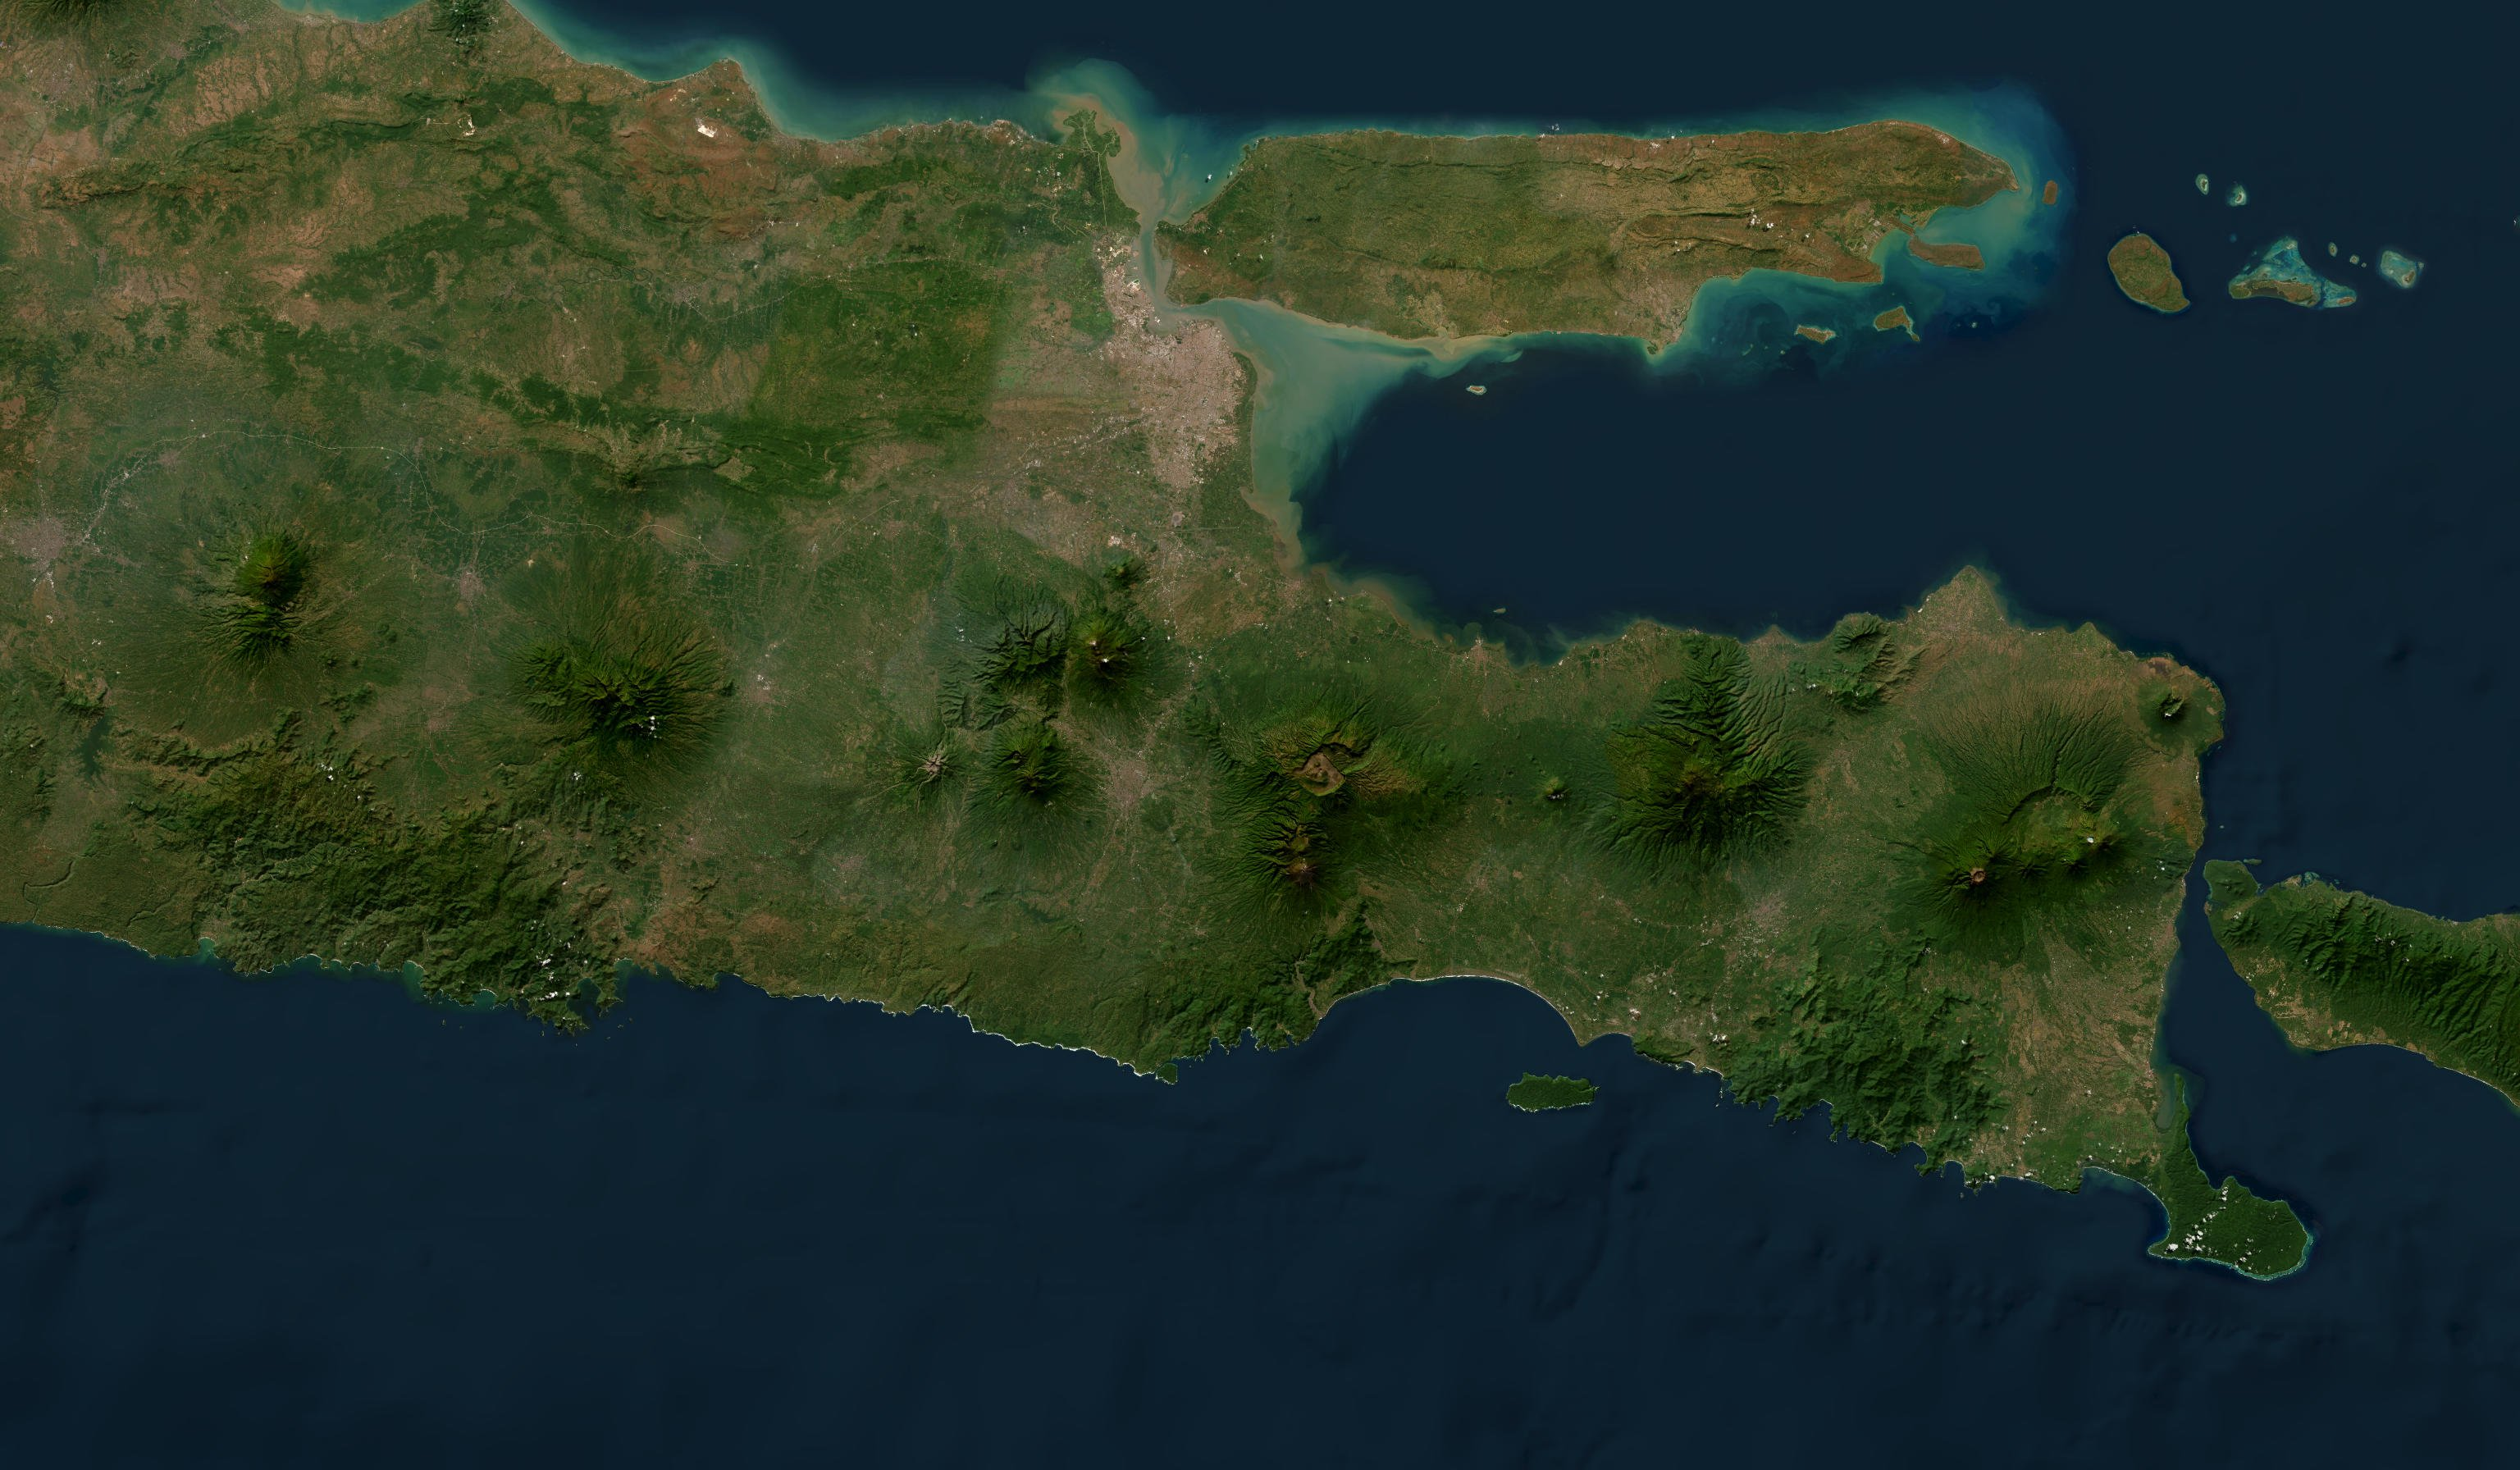
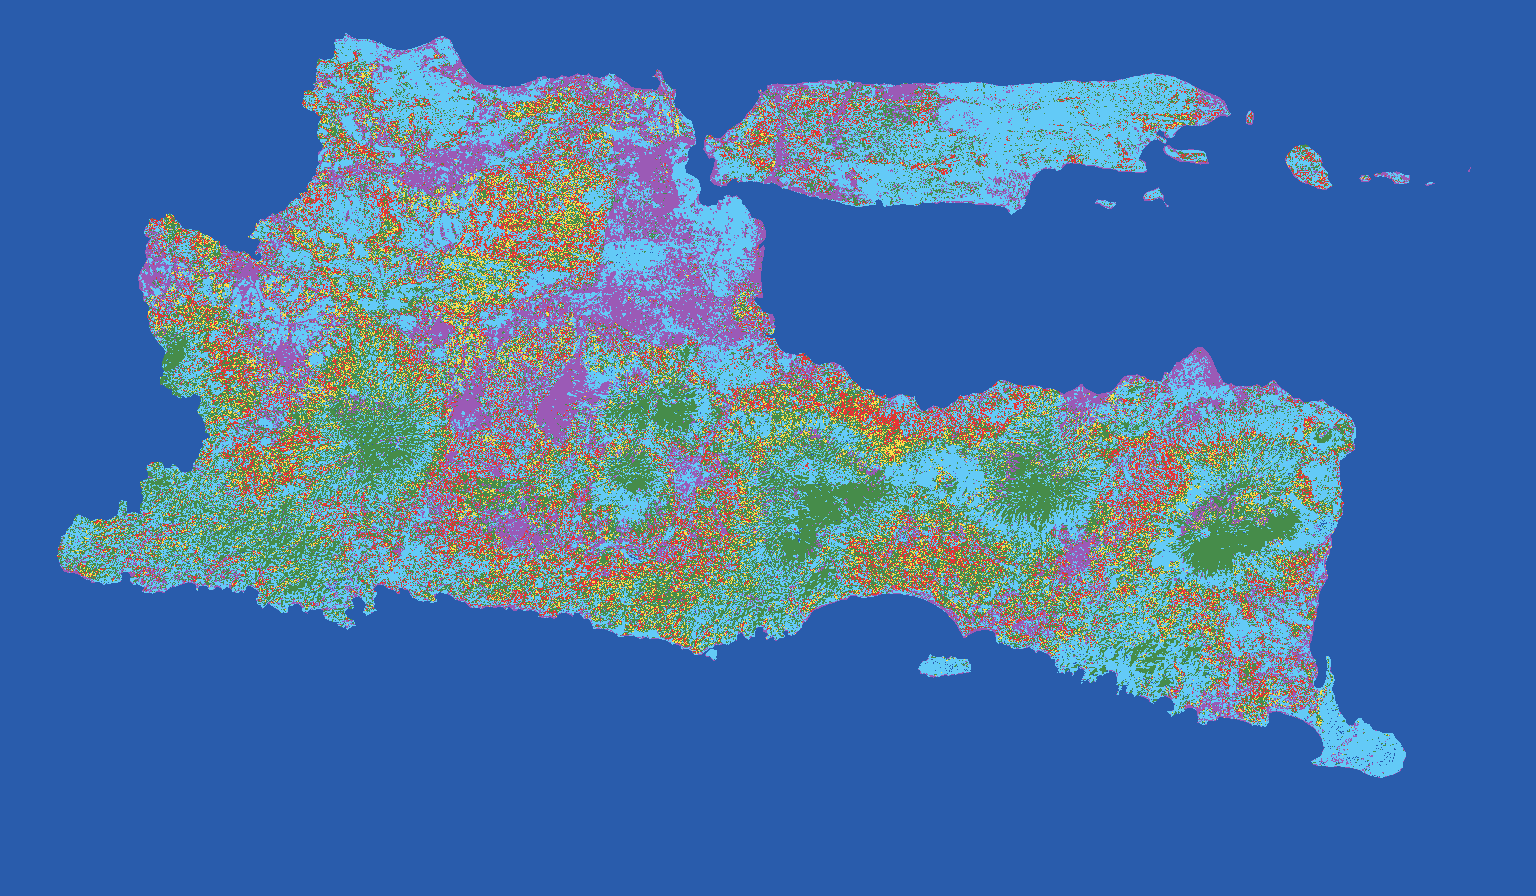

In [14]:
import os, io, math, time, requests
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import joblib
import folium
from folium.raster_layers import ImageOverlay
from PIL import Image
import geopandas as gpd
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from sklearn.ensemble import RandomForestRegressor

# ==============================================================================
# 1. KONFIGURASI AOI, KELAS, & MODEL RANDOM FOREST
# ==============================================================================
AOI = [111.0, -8.85, 114.65, -6.75]   # [barat, selatan, timur, utara] - seluruh Jawa Timur
DIR_RF = Path("hasil_rf")

URUTAN_PILIHAN = ["Sawah", "Bangunan", "Mangrove", "Lahan Hijau", "Perairan Terbuka (Laut)", "Danau"]
WARNA_KELAS = {
    "Sawah": "#FFD92F",                   # Kuning
    "Bangunan": "#E41A1C",                # Merah
    "Mangrove": "#8E44AD",                # Ungu
    "Lahan Hijau": "#2E7D32",             # Hijau Tua
    "Perairan Terbuka (Laut)": "#0D47A1", # Biru Tua
    "Danau": "#4FC3F7",                   # Biru Muda
}

MAP_NAMA = {
    "Sawah": "Sawah", "Bangunan": "Bangunan", "Hutan": "Lahan Hijau",
    "Laut": "Perairan Terbuka (Laut)", "Mangrove": "Mangrove", "Danau": "Danau",
}

def hex_ke_rgb(h):
    h = h.lstrip("#")
    return [int(h[i:i+2], 16) for i in (0, 2, 4)]

# Muat model Random Forest yang telah dilatih & data latih centroid poligon
paket = joblib.load(DIR_RF / "model_rf.joblib")
model_rf = paket["model"]
fitur = paket["fitur"]

cen = pd.read_csv(DIR_RF / "centroid_poligon.csv")
df = pd.DataFrame({
    "kelas": cen["label_teks"].map(MAP_NAMA).fillna(cen["label_teks"]),
    "lat": cen["lat_centroid"],
    "lon": cen["lon_centroid"],
})

ada = sorted(df["kelas"].unique())
NAMA_KELAS = [k for k in URUTAN_PILIHAN if k in ada] + [k for k in ada if k not in URUTAN_PILIHAN]
print("Kelas model aktif:", NAMA_KELAS)

# ==============================================================================
# 2. CITRA SATELIT TERTANAM (ESRI MOSAIC z=10)
# ==============================================================================
def koordinat_satelit(aoi, z=10):
    n = 2 ** z
    def lon_dari_x(x): return x / n * 360 - 180
    def lat_dari_y(y): return math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))
    def xy(lon, lat):
        x = (lon + 180) / 360 * n
        y = (1 - math.asinh(math.tan(math.radians(lat))) / math.pi) / 2 * n
        return x, y
    x0, y0 = xy(aoi[0], aoi[3]); x1, y1 = xy(aoi[2], aoi[1])
    xa, xb, ya, yb = int(x0), int(x1), int(y0), int(y1)
    return [[lat_dari_y(yb + 1), lon_dari_x(xa)], [lat_dari_y(ya), lon_dari_x(xb + 1)]]

def ambil_satelit(aoi, z=10):
    n = 2 ** z
    def xy(lon, lat):
        x = (lon + 180) / 360 * n
        y = (1 - math.asinh(math.tan(math.radians(lat))) / math.pi) / 2 * n
        return x, y
    def lon_dari_x(x): return x / n * 360 - 180
    def lat_dari_y(y): return math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))

    x0, y0 = xy(aoi[0], aoi[3])
    x1, y1 = xy(aoi[2], aoi[1])
    xa, xb, ya, yb = int(x0), int(x1), int(y0), int(y1)

    mosaik = Image.new("RGB", ((xb - xa + 1) * 256, (yb - ya + 1) * 256), (200, 200, 200))
    url = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"

    def unduh(xy_):
        x, y = xy_
        try:
            r = requests.get(url.format(z=z, x=x, y=y), headers={"User-Agent": "Mozilla/5.0"}, timeout=20)
            return x, y, Image.open(io.BytesIO(r.content)).convert("RGB")
        except Exception:
            return x, y, None

    ubin = [(x, y) for x in range(xa, xb + 1) for y in range(ya, yb + 1)]
    with ThreadPoolExecutor(max_workers=16) as ex:
        for x, y, im in ex.map(unduh, ubin):
            if im is not None:
                mosaik.paste(im, ((x - xa) * 256, (y - ya) * 256))

    batas = [[lat_dari_y(yb + 1), lon_dari_x(xa)], [lat_dari_y(ya), lon_dari_x(xb + 1)]]
    return mosaik, batas

FILE_SATELIT = "satelit_aoi.jpeg"
if not os.path.exists(FILE_SATELIT):
    print("Mengunduh citra satelit Esri (z=10)...")
    mosaik, batas_satelit = ambil_satelit(AOI, z=10)
    mosaik.save(FILE_SATELIT, quality=85)
else:
    print(f"Memuat citra satelit lokal dari cache: {FILE_SATELIT}")
    batas_satelit = koordinat_satelit(AOI, z=10)

img_sat = Image.open(FILE_SATELIT)

# ==============================================================================
# 3. PREDIKSI PER PIKSEL DETAIL DARI SPEKTRUM SATELIT NYATA (Tanpa Blok Besar)
# ==============================================================================
print("Memproses klasifikasi per piksel detail...")
lat_s, lon_w = batas_satelit[0]
lat_n, lon_e = batas_satelit[1]
batas_peta = batas_satelit

# Resolusi tinggi ~1536 x 896 (~200 meter per piksel, sangat detail)
W, H = 1536, 896
img_res = img_sat.resize((W, H), Image.Resampling.BILINEAR)
arr_rgb = np.array(img_res)

# Ekstrak nilai spektral RGB citra di posisi poligon sampel
def coord_to_px(lat, lon):
    c = int((lon - lon_w) / (lon_e - lon_w) * W)
    r = int((lat_n - lat) / (lat_n - lat_s) * H)
    return np.clip(r, 0, H-1), np.clip(c, 0, W-1)

rgb_samples = []
for _, row in cen.iterrows():
    r, c = coord_to_px(row['lat_centroid'], row['lon_centroid'])
    rgb_samples.append(arr_rgb[r, c, :3])

X_sampel = np.array(rgb_samples)
y_feat = cen[fitur].values

# Estimasi fitur Sentinel-2 dari spektral citra nyata
reg_mapper = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1)
reg_mapper.fit(X_sampel, y_feat)

# Mask daratan provinsi Jawa Timur
prov = gpd.read_file("jawa_timur_provinsi.geojson")
transform = from_bounds(lon_w, lat_s, lon_e, lat_n, W, H)
mask_daratan = rasterize(
    [(geom, 1) for geom in prov.geometry],
    out_shape=(H, W),
    transform=transform,
    fill=0,
    dtype=np.uint8,
)

# Klasifikasi setiap piksel daratan secara granular (piksel kecil-kecil)
idx_daratan = np.where(mask_daratan == 1)
rgb_daratan = arr_rgb[idx_daratan[0], idx_daratan[1], :3]
n_px = len(rgb_daratan)
print(f"Mengklasifikasikan {n_px:,} piksel daratan secara detail...")

feat_daratan = reg_mapper.predict(rgb_daratan)
preds_daratan = model_rf.predict(feat_daratan)
preds_daratan = np.array([MAP_NAMA.get(p, p) for p in preds_daratan])

# Susun matriks RGBA per piksel alami
rgba = np.zeros((H, W, 4), dtype=np.uint8)

# Luar daratan: perairan terbuka (laut)
idx_laut = np.where(mask_daratan == 0)
rgba[idx_laut[0], idx_laut[1]] = hex_ke_rgb(WARNA_KELAS["Perairan Terbuka (Laut)"]) + [225]

# Daratan: hasil prediksi per piksel
for k, col in WARNA_KELAS.items():
    idx_k = np.where(preds_daratan == k)[0]
    r_px = idx_daratan[0][idx_k]
    c_px = idx_daratan[1][idx_k]
    rgba[r_px, c_px] = hex_ke_rgb(col) + [225]

print("Citra klasifikasi resolusi tinggi selesai disusun!")

# ==============================================================================
# 4. MEMBANGUN PETA FOLIUM (PERSIS SESUAI STRUKTUR KODE PENGGUNA)
# ==============================================================================
pusat = [(AOI[1] + AOI[3]) / 2, (AOI[0] + AOI[2]) / 2]
peta = folium.Map(location=pusat, zoom_start=8, tiles=None, control_scale=True)

# Basemap online (untuk area di luar AOI saat dibuka di browser)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Source: Esri, Maxar, Earthstar Geographics",
    name="Esri Satellite (online)", max_zoom=19, overlay=False, control=True,
).add_to(peta)
folium.TileLayer(
    tiles="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}",
    attr="Google Hybrid", name="Google Hybrid (dengan label)",
    max_zoom=20, overlay=False, control=True, show=False,
).add_to(peta)

# LAYER BAWAH: satelit yang ditanam di dalam peta (selalu tampil, termasuk di notebook)
ImageOverlay(image=FILE_SATELIT, bounds=batas_satelit, opacity=1,
             name="Satelit (tertanam)", interactive=False, zindex=1).add_to(peta)

# LAYER ATAS: hasil klasifikasi per piksel detail
NAMA_LAYER_HASIL = "Hasil Klasifikasi Random Forest"
ImageOverlay(image=rgba, bounds=batas_peta, opacity=0.65,
             name=NAMA_LAYER_HASIL, interactive=False, zindex=5).add_to(peta)

# --- Titik sampel per kelas (default disembunyikan) ---
for nama in NAMA_KELAS:
    grup = folium.FeatureGroup(name=f"Sampel: {nama}", show=False)
    for _, r in df[df["kelas"] == nama].iterrows():
        folium.CircleMarker([r.lat, r.lon], radius=4, color="white", weight=1,
                            fill=True, fill_color=WARNA_KELAS[nama], fill_opacity=1,
                            popup=f"{nama} (lon {r.lon:.4f}, lat {r.lat:.4f})").add_to(grup)
    grup.add_to(peta)

# --- Kotak batas AOI ---
grup_aoi = folium.FeatureGroup(name="Batas area studi")
folium.Rectangle([[AOI[1], AOI[0]], [AOI[3], AOI[2]]], color="white", weight=1.5,
                 fill=False, dash_array="6").add_to(grup_aoi)
grup_aoi.add_to(peta)

# --- Legenda LULC ---
item = "".join(
    f'<div style="margin:2px 0"><span style="display:inline-block;width:14px;height:14px;'
    f'background:{WARNA_KELAS[k]};border:1px solid #333;margin-right:6px;vertical-align:middle"></span>{k}</div>'
    for k in NAMA_KELAS)
legenda = (f'<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;'
           f'padding:10px 12px;border:1px solid #888;border-radius:6px;font:13px Arial;">'
           f'<b>Legenda LULC</b><br>{item}</div>')
peta.get_root().html.add_child(folium.Element(legenda))

folium.LayerControl(collapsed=False).add_to(peta)
peta.fit_bounds([[AOI[1], AOI[0]], [AOI[3], AOI[2]]])

nama_html = "hasil_klasifikasi_random_forest.html"
peta.save(nama_html)
print(f"Peta disimpan: {nama_html} (dapat ditanam di web statis lewat <iframe>)")
peta